# $(SASA) Regular$

$loss = \alpha \times mse(\hat{\theta_i^a}, \hat{\theta_j^a}) + \beta \times (1-mse(\hat{\theta_i^a}, \hat{\theta_k^b})) + \gamma \times mse(\hat{s_{i+2}^a}, y) + \lambda(\hat{\theta_i^a}^2 + \hat{\theta_k^b}^2 + \hat{\theta_j^a}^2)$

## Experimento Validação

- 100 episódios de Treino
- 10 episódios de Validação
- 1 agente

* Cada agente é treinado com 800 passos dos episódios de treino e testado em 200, os passos de todos os episodios sao embaralhados aleatoriamente
* Resultado intermedário é uma comparacao do parametro estimado em cada passo de teste com o parametro real
* Os a gentes são validados em cada passo dos episódios de validação
* Resultado final é comparacao do parametro estimado em cada passo pelos agentes com o parametro real

In [1]:
import matplotlib.pyplot as plt

from pmbrl.model2 import Model
from pmbrl.data import Experiment_Data, get_data_expanded

# Training

In [2]:
data = Experiment_Data()

data.load(path='training_data.csv')
data.build_training_dataset()

,step,episode,p,s,a,r,s_,a_,r_,s__
1938,0,83,"(0.79, 1.8)","(-0.018, -0.046, 0.013, -0.019)",0,1.0,"(-0.019, -0.235, 0.013, 0.147)",1.0,1.0,"(-0.024, -0.046, 0.015, -0.015)"
849,23,37,"(0.35, 1.8)","(-0.154, -0.913, 0.045, 0.473)",1,1.0,"(-0.172, -0.727, 0.054, 0.379)",1.0,1.0,"(-0.187, -0.541, 0.062, 0.285)"
516,7,24,"(0.68, 1.3)","(-0.053, -0.201, 0.044, 0.22)",1,1.0,"(-0.057, -0.011, 0.048, 0.034)",0.0,1.0,"(-0.057, -0.202, 0.049, 0.239)"
1372,4,59,"(0.36, 0.2)","(-0.006, -0.409, 0.029, 1.71)",0,1.0,"(-0.014, -0.633, 0.063, 2.641)",0.0,1.0,"(-0.027, -0.858, 0.116, 3.601)"
381,0,18,"(0.03, 1.4)","(-0.01, 0.022, -0.022, -0.042)",1,1.0,"(-0.01, 0.208, -0.023, -0.143)",1.0,1.0,"(-0.005, 0.395, -0.026, -0.245)"
...,...,...,...,...,...,...,...,...,...,...
1082,2,48,"(0.51, 0.5)","(-0.015, 0.01, 0.011, 0.021)",0,1.0,"(-0.015, -0.192, 0.011, 0.444)",0.0,1.0,"(-0.019, -0.393, 0.02, 0.867)"
360,6,17,"(0.79, 0.8)","(0.066, -0.032, -0.063, -0.056)",0,1.0,"(0.066, -0.229, -0.064, 0.286)",1.0,1.0,"(0.061, -0.03, -0.058, -0.106)"
99,19,4,"(0.65, 1.6)","(0.153, 0.565, -0.039, -0.44)",1,1.0,"(0.165, 0.754, -0.048, -0.599)",1.0,1.0,"(0.18, 0.943, -0.06, -0.76)"
1253,7,53,"(0.84, 0.7)","(-0.025, 0.23, -0.062, -0.539)",1,1.0,"(-0.021, 0.434, -0.073, -1.022)",1.0,1.0,"(-0.012, 0.638, -0.093, -1.509)"


In [3]:
model = Model()

loss_param=1e-5

x, y = model.get_features_targets(data.training_dataset)
trainer = model.train(x, y, num_epochs=500, alpha=loss_param, beta=loss_param, lambda_=loss_param)
train_data = data.get_training_data(trainer, inference_schema=model.inference_schema)
train_data.head()

,epoch,mse_positive,mse_negative,mse_s,regularize,transition,reward
0,0,"[1.0285062789916992, 2.261228084564209]","[1.0164854526519775, 2.2726099491119385]","[0.02750231884419918, 0.7183458805084229, 0.03...",2.018199,1.656535,2.279544
1,1,"[1.0197890996932983, 2.27154541015625]","[1.0079469680786133, 2.282841444015503]","[0.026585055515170097, 0.7103734612464905, 0.0...",2.017473,1.642829,2.272021
2,2,"[1.0111178159713745, 2.2826695442199707]","[0.9994543194770813, 2.293912887573242]","[0.025715351104736328, 0.7025283575057983, 0.0...",2.016887,1.629402,2.264515
3,3,"[1.0024982690811157, 2.294059991836548]","[0.991014301776886, 2.30526065826416]","[0.024891873821616173, 0.6947900056838989, 0.0...",2.016387,1.616243,2.256824
4,4,"[0.9939405918121338, 2.305595874786377]","[0.9826366305351257, 2.316761016845703]","[0.024114321917295456, 0.687132716178894, 0.02...",2.015963,1.603328,2.248916


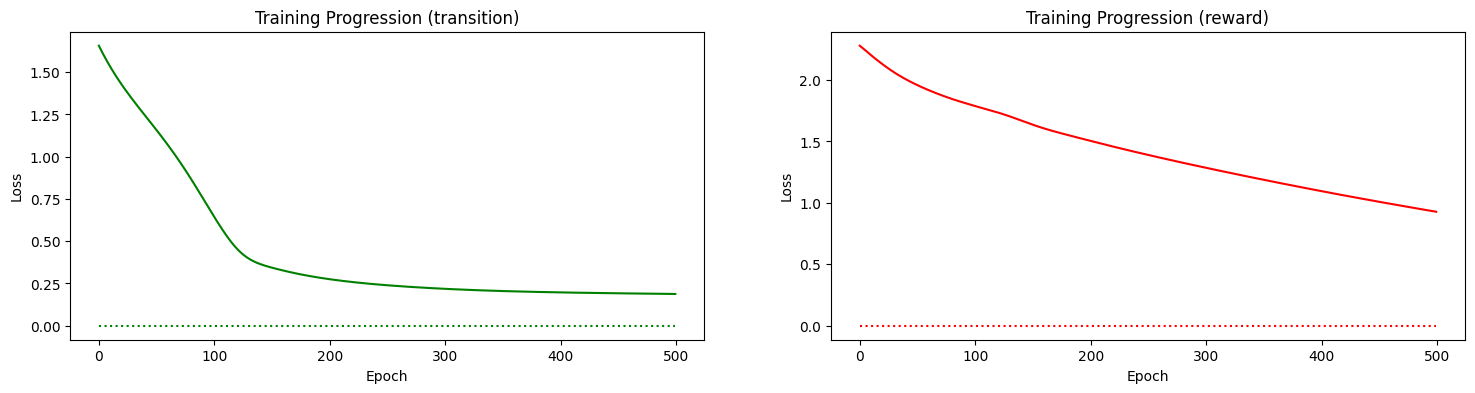

In [4]:
fig, axs = plt.subplots(1, 2, figsize=(18, 4))

data.plot_training_loss(axs[0])
data.plot_training_loss(axs[1], train_data.reward, 'r')

plt.show()

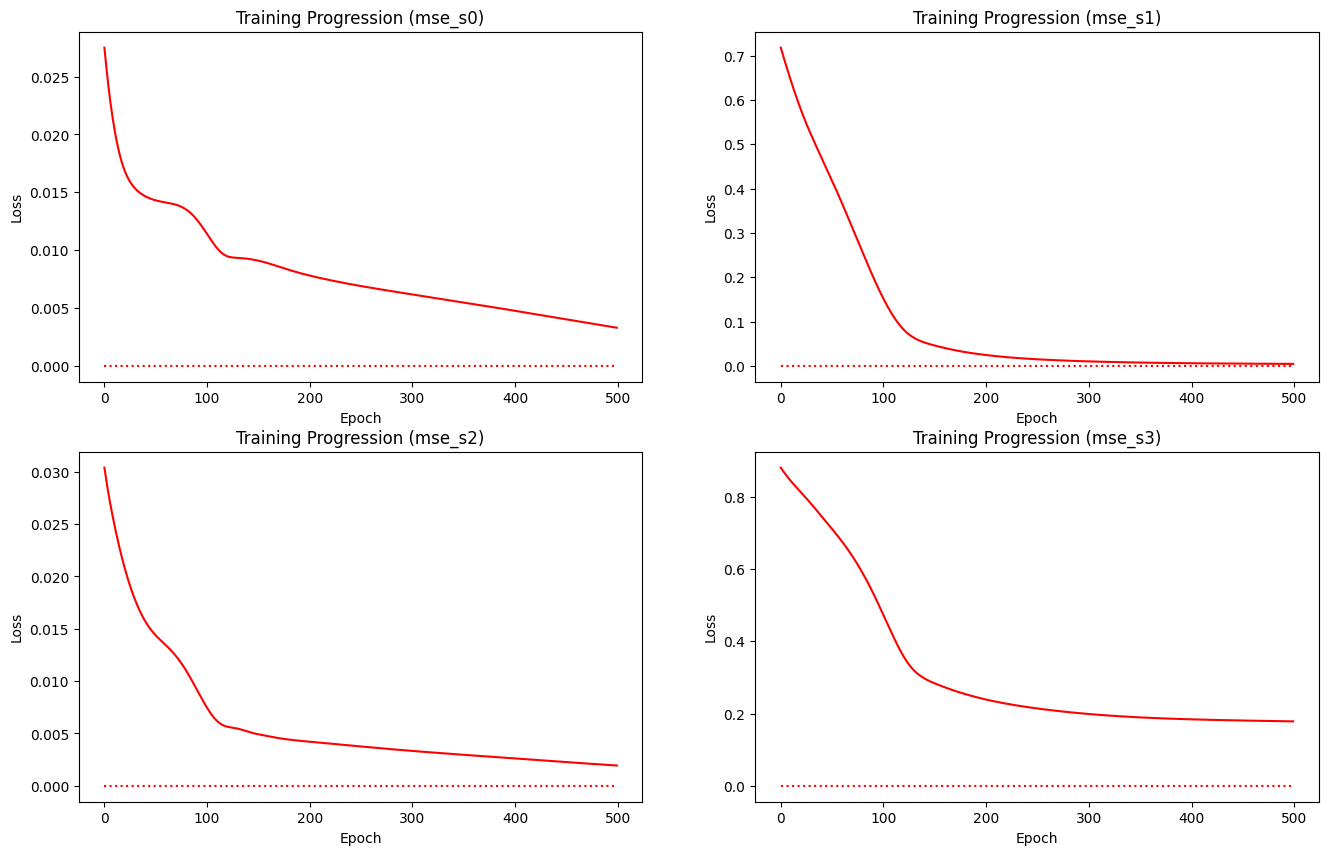

In [5]:
fig, axs = plt.subplots(2, 2, figsize=(16, 10))

expansions = {
    'mse_s': ['mse_s0', 'mse_s1', 'mse_s2', 'mse_s3'],
    'mse_negative': ['mse_negative_p0', 'mse_negative_p1'],
    'mse_positive': ['mse_positive_p0', 'mse_positive_p1'],
}

df = get_data_expanded(train_data, expansions)

for i,col in enumerate(expansions['mse_s']):
    data.plot_training_loss(axs[i//2][i%2], df[col], 'r')

plt.show()

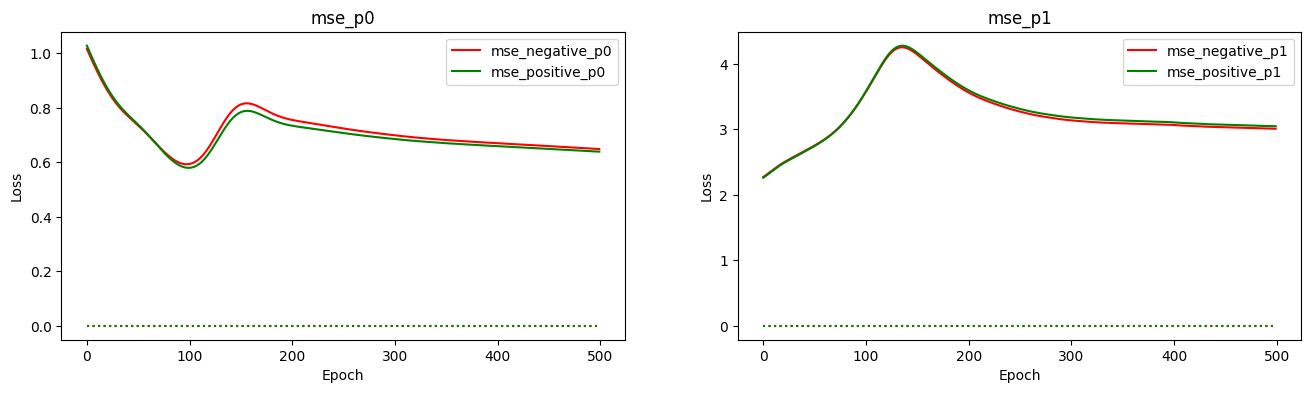

In [6]:
fig, axs = plt.subplots(1, 2, figsize=(16, 4))

expansions = {
    'mse_s': ['mse_s0', 'mse_s1', 'mse_s2', 'mse_s3'],
    'mse_negative': ['mse_negative_p0', 'mse_negative_p1'],
    'mse_positive': ['mse_positive_p0', 'mse_positive_p1'],
}

df = get_data_expanded(train_data, expansions)

for i,(neg, pos) in enumerate(zip(expansions['mse_negative'], expansions['mse_positive'])):
    data.plot_training_loss(axs[i], df[neg], 'r')
    data.plot_training_loss(axs[i], df[pos], 'g')
    axs[i].set_title(f'mse_p{i}')
    axs[i].legend()

plt.show()

# Evaluation

In [7]:
results = data.evaluate_model(model, path='testing_data.csv')
results.head()

,step,episode,p,s,a,r,s_,a_,r_,s__,estimated_s,estimated_p,estimated_r
0,0,0,"(0.62, 1.2)","(-0.005, -0.042, -0.019, -0.009)",0,1.0,"(-0.006, -0.233, -0.02, 0.183)",1.0,1.0,"(-0.01, -0.042, -0.016, -0.018)","(-0.034, -0.027, -0.004, -0.085)","(-0.241, 0.074)",0.0
1,1,0,"(0.62, 1.2)","(-0.006, -0.233, -0.02, 0.183)",1,1.0,"(-0.01, -0.042, -0.016, -0.018)",1.0,1.0,"(-0.011, 0.149, -0.016, -0.218)","(-0.032, 0.179, 0.016, -0.307)","(-0.244, -0.306)",-0.0
2,2,0,"(0.62, 1.2)","(-0.01, -0.042, -0.016, -0.018)",1,1.0,"(-0.011, 0.149, -0.016, -0.218)",1.0,1.0,"(-0.008, 0.34, -0.021, -0.418)","(-0.004, 0.371, -0.002, -0.521)","(-0.138, -0.578)",-0.0
3,3,0,"(0.62, 1.2)","(-0.011, 0.149, -0.016, -0.218)",1,1.0,"(-0.008, 0.34, -0.021, -0.418)",1.0,1.0,"(-0.001, 0.531, -0.029, -0.619)","(0.029, 0.526, -0.022, -0.734)","(-0.053, -0.793)",-0.0
4,4,0,"(0.62, 1.2)","(-0.008, 0.34, -0.021, -0.418)",1,1.0,"(-0.001, 0.531, -0.029, -0.619)",1.0,1.0,"(0.009, 0.722, -0.041, -0.822)","(0.066, 0.7, -0.046, -0.939)","(0.063, -1.051)",0.0


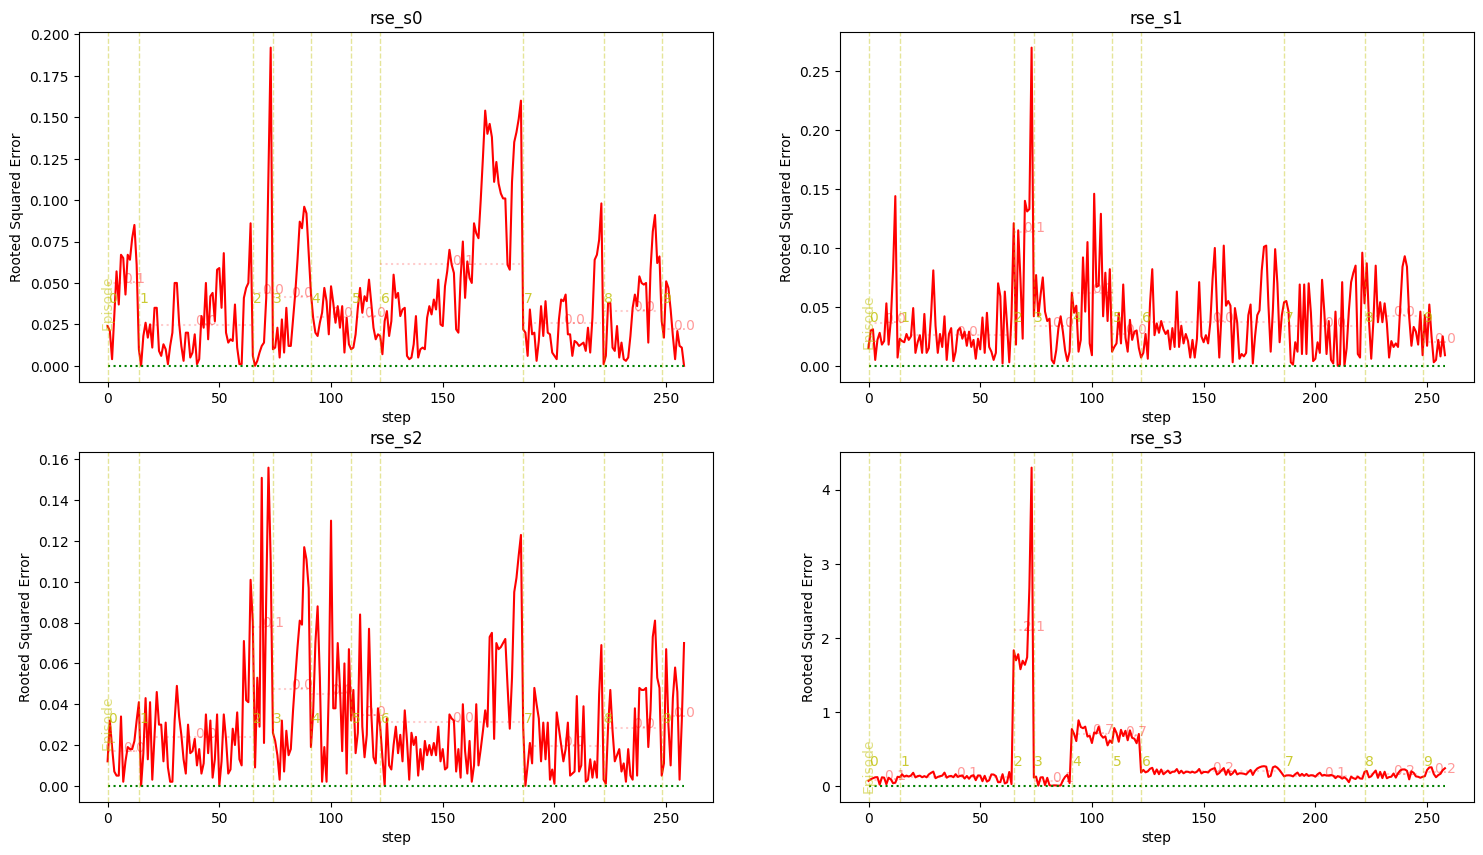

In [8]:
fig, axs = plt.subplots(2, 2, figsize=(18,10))

data.plot_value_through_episodes(axs[0][0], results, 'rse_s0')
data.plot_value_through_episodes(axs[0][1], results, 'rse_s1')
data.plot_value_through_episodes(axs[1][0], results, 'rse_s2')
data.plot_value_through_episodes(axs[1][1], results, 'rse_s3')

plt.show()

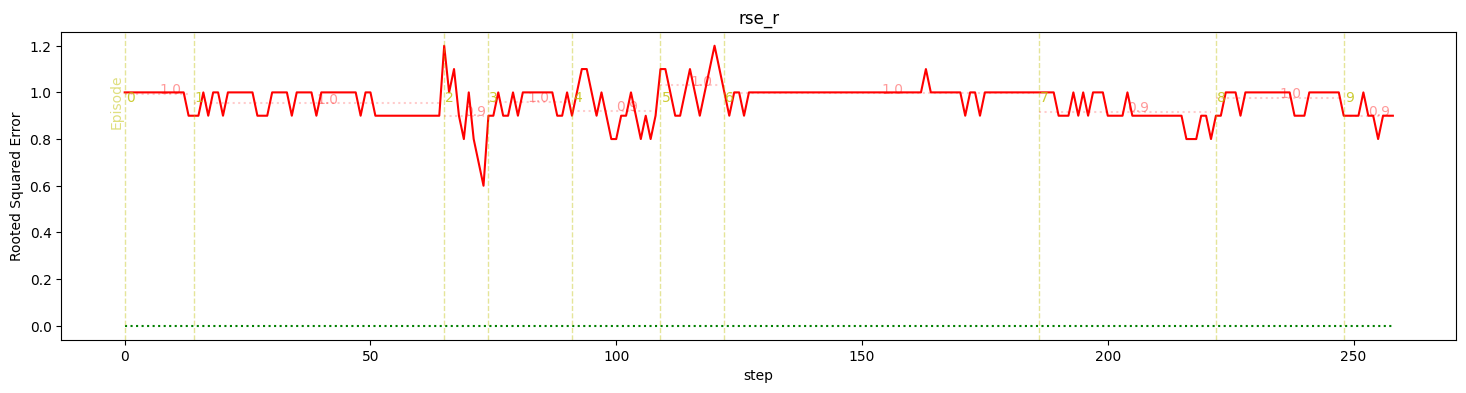

In [9]:
fig, axs = plt.subplots(1, 1, figsize=(18,4))
data.plot_value_through_episodes(axs, results, 'rse_r')
plt.show()

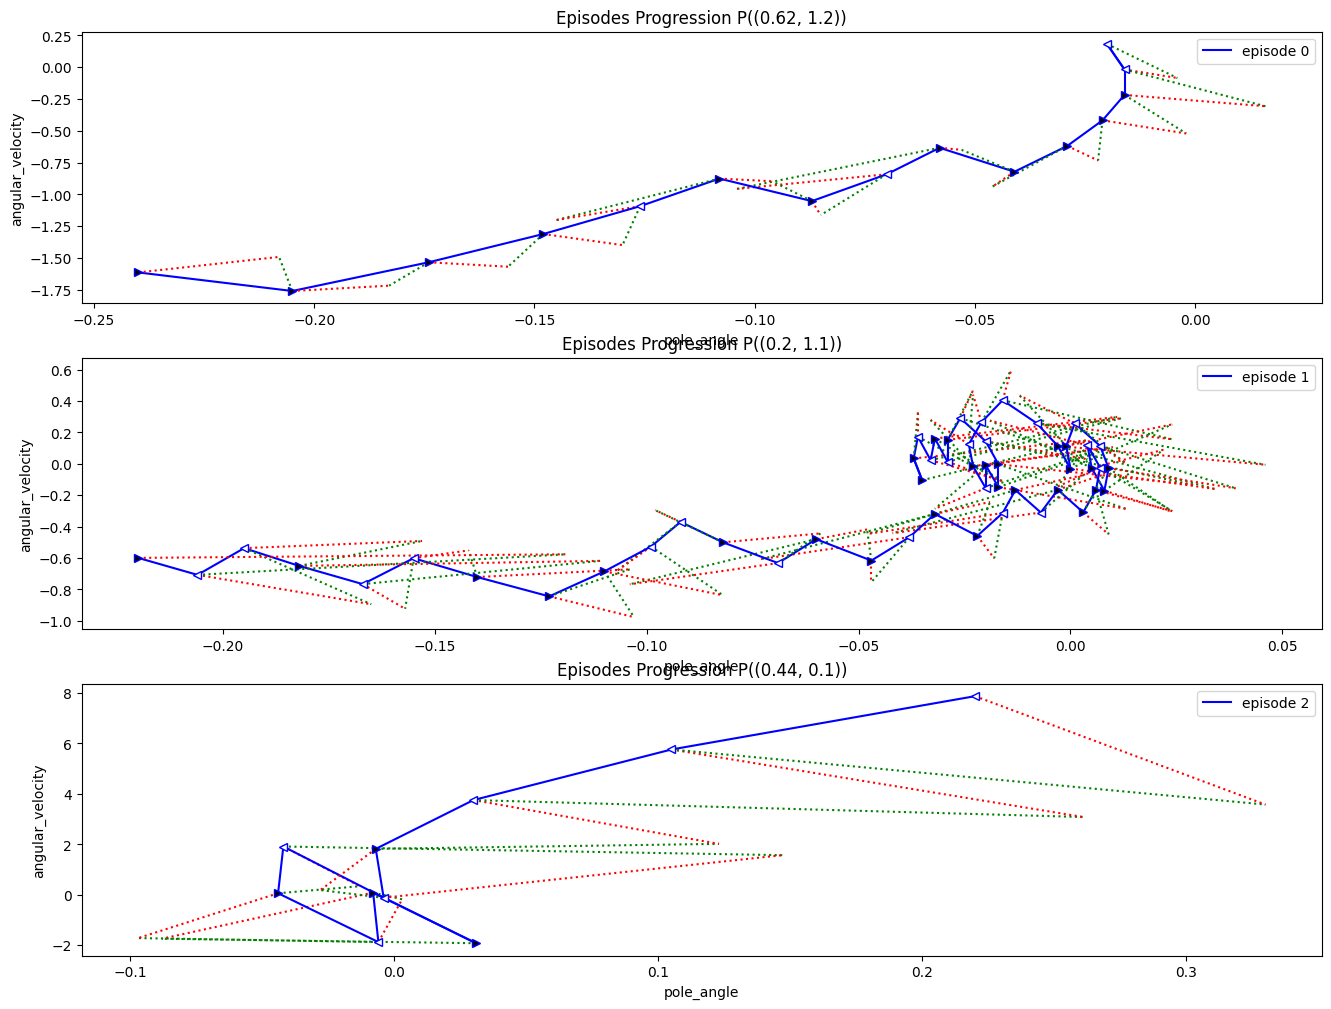

In [10]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(3, 1, figsize=(16, 12))
data.plot_episode_progression_with_predictions(axs[0], 0)
data.plot_episode_progression_with_predictions(axs[1], 1)
data.plot_episode_progression_with_predictions(axs[2], 2)
plt.show()